# Prediksi Kekurangan Tenaga Medis — Sulawesi Tenggara
**Tujuan:** input *nama wilayah + tahun* → prediksi selisih tenaga medis.

**Selisih = Tenaga medis aktual − Tenaga medis ideal** (negatif = kekurangan, positif = kelebihan)

**Algoritma:** Linear Regression (satu model untuk tiap wilayah)

Alur: Dataset → Cleaning → EDA → Feature Selection → Train-Test Split → Pemodelan → Evaluasi → Prediksi → Kesimpulan

## 1. Pengumpulan Dataset

In [1]:
from google.colab import files
files.upload()   # pilih file dataset_master_sultra.csv

Saving dataset_master_sultra.csv to dataset_master_sultra.csv


{'dataset_master_sultra.csv': b'\xef\xbb\xbfKabupaten_Kota;Tahun;Jumlah_Penduduk;Jumlah_Tenaga_Medis\r\nBaubau;2015;154.877;69\r\nBaubau;2016;158.271;110\r\nBaubau;2017;162.780;112\r\nBaubau;2018;167.519;63\r\nBaubau;2019;171.802;135\r\nBaubau;2020;158.820;95\r\nBaubau;2021;161.280;118\r\nBaubau;2022;163.720;113\r\nBaubau;2023;166.150;133\r\nBaubau;2024;168.500;162\r\nBaubau;2025;170.900;183\r\nBombana;2015;164.809;54\r\nBombana;2016;170.020;41\r\nBombana;2017;175.497;61\r\nBombana;2018;180.035;50\r\nBombana;2019;184.570;44\r\nBombana;2020;150.160;64\r\nBombana;2021;152.860;67\r\nBombana;2022;155.510;71\r\nBombana;2023;158.110;74\r\nBombana;2024;160.700;106\r\nBombana;2025;163.200;126\r\nButon;2015;97.670;41\r\nButon;2016;99.352;41\r\nButon;2017;100.440;49\r\nButon;2018;101.618;23\r\nButon;2019;102.641;33\r\nButon;2020;114.800;44\r\nButon;2021;116.600;58\r\nButon;2022;118.410;71\r\nButon;2023;120.210;74\r\nButon;2024;122.000;79\r\nButon;2025;123.900;111\r\nButon Selatan;2015;77.547;4\r

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Titik pada Jumlah_Penduduk adalah pemisah ribuan, jadi dibaca sebagai teks dulu
df = pd.read_csv('dataset_master_sultra.csv', sep=';', dtype={'Jumlah_Penduduk': str})

print("Ukuran data:", df.shape)
display(df.head())

Ukuran data: (187, 4)


,Kabupaten_Kota,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis
0,Baubau,2015,154.877,69
1,Baubau,2016,158.271,110
2,Baubau,2017,162.780,112
3,Baubau,2018,167.519,63
4,Baubau,2019,171.802,135


## 2. Cleaning & Preprocessing

In [3]:
# "162.780" -> 162780
df['Jumlah_Penduduk'] = df['Jumlah_Penduduk'].str.replace('.', '', regex=False).astype(int)

# Membuat target: selisih tenaga medis
# Standar ideal: 0,8 tenaga medis per 1.000 penduduk
df['Tenaga_Medis_Ideal'] = df['Jumlah_Penduduk'] * 0.8 / 1000
df['Selisih'] = df['Jumlah_Tenaga_Medis'] - df['Tenaga_Medis_Ideal']

print("Missing value :", df.isnull().sum().sum())
print("Data duplikat :", df.duplicated().sum())
display(df.head())

Missing value : 0
Data duplikat : 0


,Kabupaten_Kota,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis,Tenaga_Medis_Ideal,Selisih
0,Baubau,2015,154877,69,123.9016,-54.9016
1,Baubau,2016,158271,110,126.6168,-16.6168
2,Baubau,2017,162780,112,130.2240,-18.2240
3,Baubau,2018,167519,63,134.0152,-71.0152
4,Baubau,2019,171802,135,137.4416,-2.4416


## 3. Exploratory Data Analysis (EDA)

,Jumlah_Penduduk,Jumlah_Tenaga_Medis,Selisih
count,187.000000,187.000000,187.000000
mean,157059.347594,73.122995,-52.524483
std,91287.236653,95.322491,73.022023
min,31688.000000,3.000000,-210.371200
25%,89289.500000,28.500000,-78.718800
50%,125859.000000,48.000000,-47.840000
75%,224394.500000,77.000000,-26.132800
max,392830.000000,725.000000,423.160000


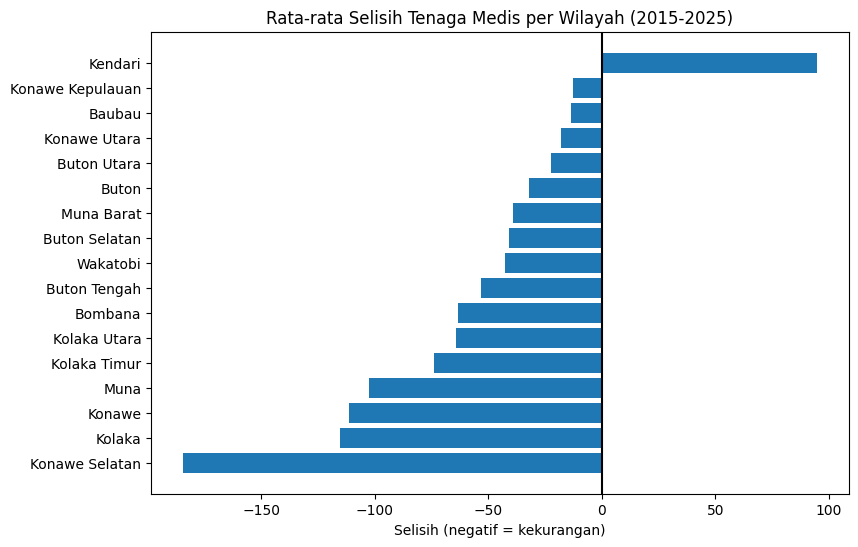

In [4]:
display(df[['Jumlah_Penduduk', 'Jumlah_Tenaga_Medis', 'Selisih']].describe())

# Rata-rata selisih tiap wilayah
rata = df.groupby('Kabupaten_Kota')['Selisih'].mean().sort_values()

plt.figure(figsize=(9, 6))
plt.barh(rata.index, rata.values)
plt.axvline(0, color='black')
plt.title('Rata-rata Selisih Tenaga Medis per Wilayah (2015-2025)')
plt.xlabel('Selisih (negatif = kekurangan)')
plt.show()

## 4. Feature Selection
- **Fitur (X):** `Tahun`
- **Target (y):** `Selisih`
- `Jumlah_Penduduk` dan `Jumlah_Tenaga_Medis` **tidak dipakai sebagai fitur** karena keduanya adalah bahan penghitung target. Jika dipakai, model hanya "menghitung ulang rumus" dan tidak bisa dipakai memprediksi tahun depan (nilai penduduk tahun depan belum diketahui).
- Nama wilayah tidak dijadikan fitur, tetapi dipakai untuk membuat model terpisah per wilayah.

In [5]:
fitur = ['Tahun']
target = 'Selisih'
print("Fitur :", fitur)
print("Target:", target)

Fitur : ['Tahun']
Target: Selisih


## 5. Train-Test Split
Data berupa deret waktu, jadi dibagi **berdasarkan tahun** (bukan acak): latih 2015-2024, uji 2025.

In [6]:
train = df[df['Tahun'] <= 2024]
test = df[df['Tahun'] == 2025]

print("Data latih :", len(train), "baris (2015-2024)")
print("Data uji   :", len(test), "baris (2025)")

Data latih : 170 baris (2015-2024)
Data uji   : 17 baris (2025)


## 6. Pemodelan (Linear Regression)

In [7]:
from sklearn.linear_model import LinearRegression

# Satu model per wilayah: Tahun -> Selisih
def latih_model(data):
    model = {}
    for wilayah, d in data.groupby('Kabupaten_Kota'):
        m = LinearRegression()
        m.fit(d[fitur].values, d[target])
        model[wilayah] = m
    return model

model_uji = latih_model(train)
print("Model berhasil dilatih untuk", len(model_uji), "wilayah")

Model berhasil dilatih untuk 17 wilayah


## 7. Evaluasi Model

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test = test.copy()
test['Prediksi'] = [model_uji[w].predict([[t]])[0]
                    for w, t in zip(test['Kabupaten_Kota'], test['Tahun'])]

mae = mean_absolute_error(test[target], test['Prediksi'])
rmse = np.sqrt(mean_squared_error(test[target], test['Prediksi']))
r2 = r2_score(test[target], test['Prediksi'])

print(f"MAE  : {mae:.1f}  (rata-rata error, satuan tenaga medis)")
print(f"RMSE : {rmse:.1f}")
print(f"R2   : {r2:.3f}")

display(test[['Kabupaten_Kota', 'Selisih', 'Prediksi']].round(1))

MAE  : 24.5  (rata-rata error, satuan tenaga medis)
RMSE : 36.0
R2   : 0.904


,Kabupaten_Kota,Selisih,Prediksi
10,Baubau,46.3,13.9
21,Bombana,-4.6,-32.7
32,Buton,11.9,-23.2
43,Buton Selatan,-33.2,-28.5
54,Buton Tengah,-41.5,-52.7
65,Buton Utara,5.5,-15.6
76,Kendari,423.2,306.0
87,Kolaka,-47.2,-82.4
98,Kolaka Timur,-70.4,-60.7
109,Kolaka Utara,-49.1,-41.3
